1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


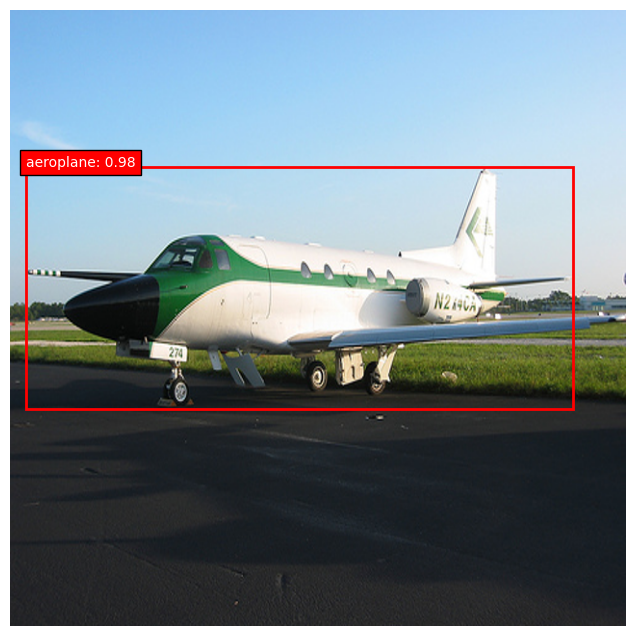


Image 1 detections:
Object: aeroplane  Confidence: 0.98


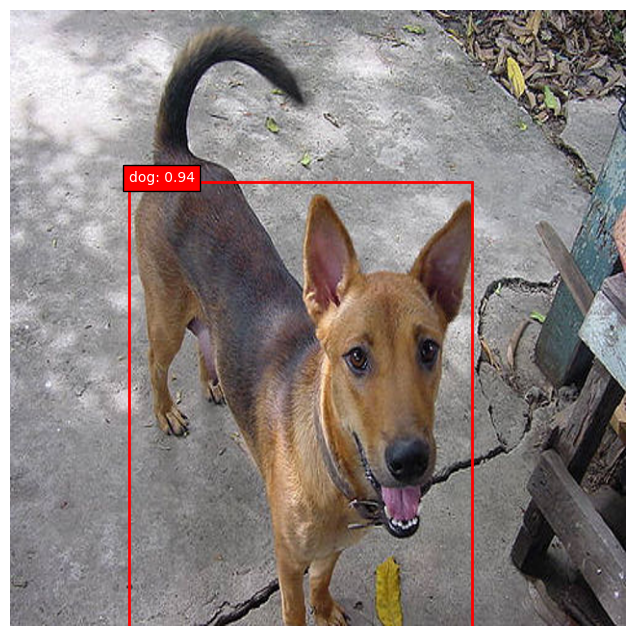


Image 2 detections:
Object: dog  Confidence: 0.94


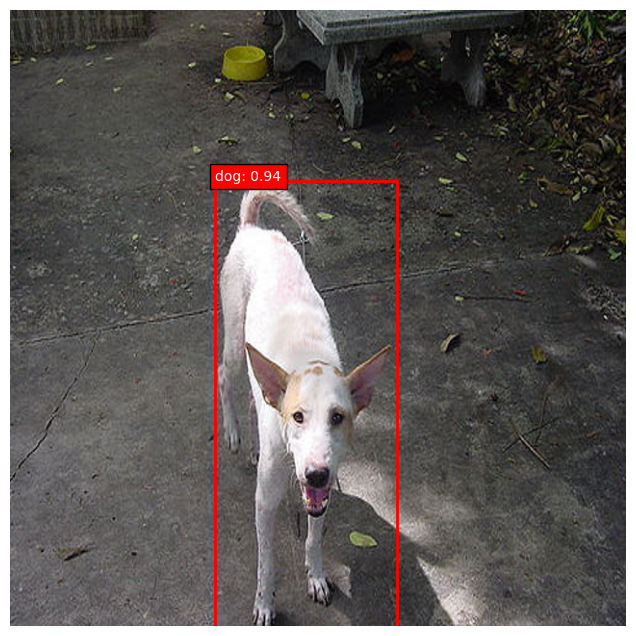


Image 3 detections:
Object: dog  Confidence: 0.94


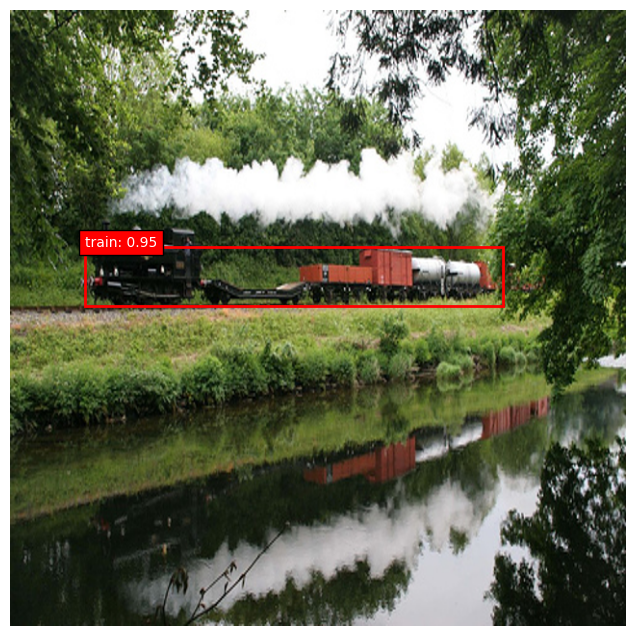


Image 4 detections:
Object: train  Confidence: 0.95


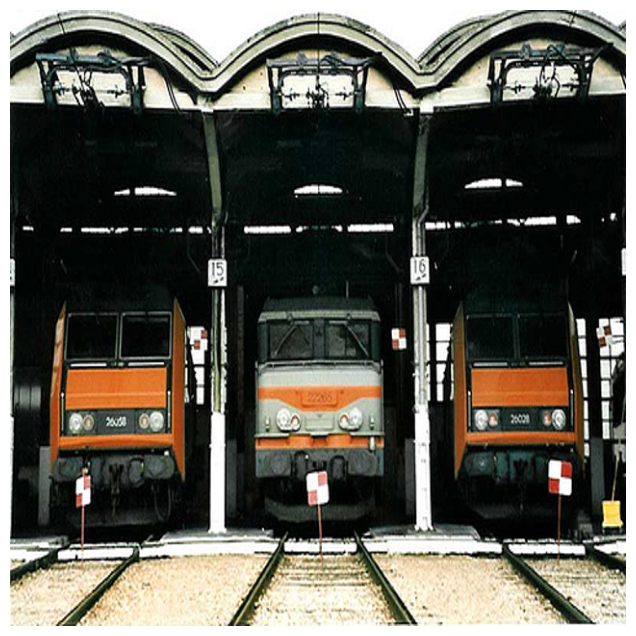


Image 5 detections:


In [ ]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


voc_classes = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]


model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)


inference_resizing = keras_cv.layers.Resizing(
    640,
    640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)


image_paths = [
    "/Users/layanal-umair/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/2008_000012.jpg",
    "/Users/layanal-umair/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/2008_000030.jpg",
    "/Users/layanal-umair/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/2008_000031.jpg",
    "/Users/layanal-umair/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/2008_000083.jpg",
    "/Users/layanal-umair/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/2008_000088.jpg"
]


images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize((640,640))  
    img = np.array(img)
    images.append(img)


images = np.stack(images, axis=0)


resized_images = inference_resizing(images)


predictions = model.predict(resized_images)


def visualize(image, boxes, classes, scores):

    plt.figure(figsize=(8,8))
    plt.imshow(image.astype("uint8"))
    ax = plt.gca()

    for box, cls, score in zip(boxes, classes, scores):

        if score < 0.3:
            continue

        x, y, w, h = box

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            color="red",
            linewidth=2
        )

        ax.add_patch(rect)

        label = voc_classes[int(cls)]

        ax.text(
            x,
            y,
            f"{label}: {score:.2f}",
            color="white",
            bbox=dict(facecolor="red")
        )

    plt.axis("off")
    plt.show()



for i in range(len(images)):

    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    scores = predictions["confidence"][i]

    visualize(images[i], boxes, classes, scores)

    print(f"\nImage {i+1} detections:")

    for cls, score in zip(classes, scores):
        if score > 0.3:
            label = voc_classes[int(cls)]
            print(f"Object: {label}  Confidence: {score:.2f}")